# Peak/Off-Peak Price Analysis

How do batteries affect the peak-offpeak price spread, technology capture rates,
and temporal structure of cross-border tail dependence?

- **Peak:** 08:00–19:59, Monday–Friday (~3132 hours/year)
- **Off-peak:** all other hours (~5628 hours/year)

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path(".").resolve().parent
DATA = ROOT / "data" / "tyndp2024" / "preprocessed" / "solved"

# === Load ALL data once ===
results = pd.read_csv(ROOT / "solved_networks_core" / "solve_results.csv")
results = results[results["status"] == "solved"].copy()

static_gen = pd.read_parquet(DATA / "static_generators.parquet")
static_su = pd.read_parquet(DATA / "static_storage_units.parquet")

print("Loading lmp.parquet...")
lmp_all = pd.read_parquet(DATA / "lmp.parquet")
bus_cols = [c for c in lmp_all.columns if c not in ("tag", "timestamp")]

print("Loading gen_p.parquet...")
gen_p_all = pd.read_parquet(DATA / "gen_p.parquet")
gen_cols = [c for c in gen_p_all.columns if c not in ("tag", "timestamp")]

print("Loading storage_p.parquet...")
stor_p_all = pd.read_parquet(DATA / "storage_p.parquet")
stor_cols = [c for c in stor_p_all.columns if c not in ("tag", "timestamp")]

# Peak/off-peak classification
def classify_peak(timestamps):
    """Return boolean array: True = peak (08-20 Mon-Fri)."""
    ts = pd.to_datetime(timestamps)
    return (ts.dt.hour >= 8) & (ts.dt.hour < 20) & (ts.dt.weekday < 5)

lmp_all["is_peak"] = classify_peak(lmp_all["timestamp"])

# Corridors for tail dependence
CORRIDORS = [
    ("DE00", "FR00"), ("DE00", "NL00"), ("DE00", "PL00"), ("DE00", "AT00"),
    ("FR00", "ES00"), ("FR00", "BE00"), ("FR00", "GB00"), ("NOS0", "DE00"),
    ("SE01", "FI00"), ("DE00", "CZ00"), ("ITN1", "AT00"), ("DKW1", "DE00"),
]
CORRIDOR_LABELS = [f"{a}\u2013{b}" for a, b in CORRIDORS]

KEY_CARRIERS = ["solar-pv-utility", "onwind", "offwind", "gas", "nuclear", "hydro-ror"]

print(f"\nAll data loaded:")
print(f"  Scenarios: {len(results)}")
print(f"  LMP: {lmp_all.shape[0]} rows, {len(bus_cols)} zones")
print(f"  gen_p: {gen_p_all.shape[0]} rows, {len(gen_cols)} generators")
print(f"  storage_p: {stor_p_all.shape[0]} rows, {len(stor_cols)} units")
print(f"  Peak hours per scenario: {lmp_all.groupby('tag')['is_peak'].sum().iloc[0]:.0f}")

Loading lmp.parquet...
Loading gen_p.parquet...
Loading storage_p.parquet...

All data loaded:
  Scenarios: 432
  LMP: 3784320 rows, 55 zones
  gen_p: 3784320 rows, 557 generators
  storage_p: 3784320 rows, 119 units
  Peak hours per scenario: 3132


## A. Peak-Offpeak Spread

Spread = mean_peak_LMP − mean_offpeak_LMP (EUR/MWh) per zone per scenario.
Batteries should compress this spread by charging off-peak and discharging at peak.

In [38]:
# Compute spread per scenario x zone (data already loaded in Cell 1)
spread_records = []
for i, tag in enumerate(results["tag"].values):
    lmp_tag = lmp_all[lmp_all["tag"] == tag]
    peak = lmp_tag[lmp_tag["is_peak"]][bus_cols].mean()
    offpeak = lmp_tag[~lmp_tag["is_peak"]][bus_cols].mean()
    spread = peak - offpeak

    for zone in bus_cols:
        spread_records.append({
            "tag": tag, "zone": zone,
            "mean_peak": peak[zone], "mean_offpeak": offpeak[zone],
            "spread": spread[zone],
        })
    if (i + 1) % 100 == 0:
        print(f"  Processed {i+1}/432...")

spread_df = pd.DataFrame(spread_records).merge(
    results[["tag", "battery_scale", "battery_duration", "gas_price", "co2_price", "climate_year"]],
    on="tag"
)
print(f"Spread data: {len(spread_df)} rows")
print(f"Mean spread by bat_scale: {spread_df.groupby('battery_scale')['spread'].mean().round(2).to_dict()}")
print(f"Mean spread by bat_duration: {spread_df.groupby('battery_duration')['spread'].mean().round(2).to_dict()}")

  Processed 100/432...
  Processed 200/432...
  Processed 300/432...


KeyboardInterrupt: 

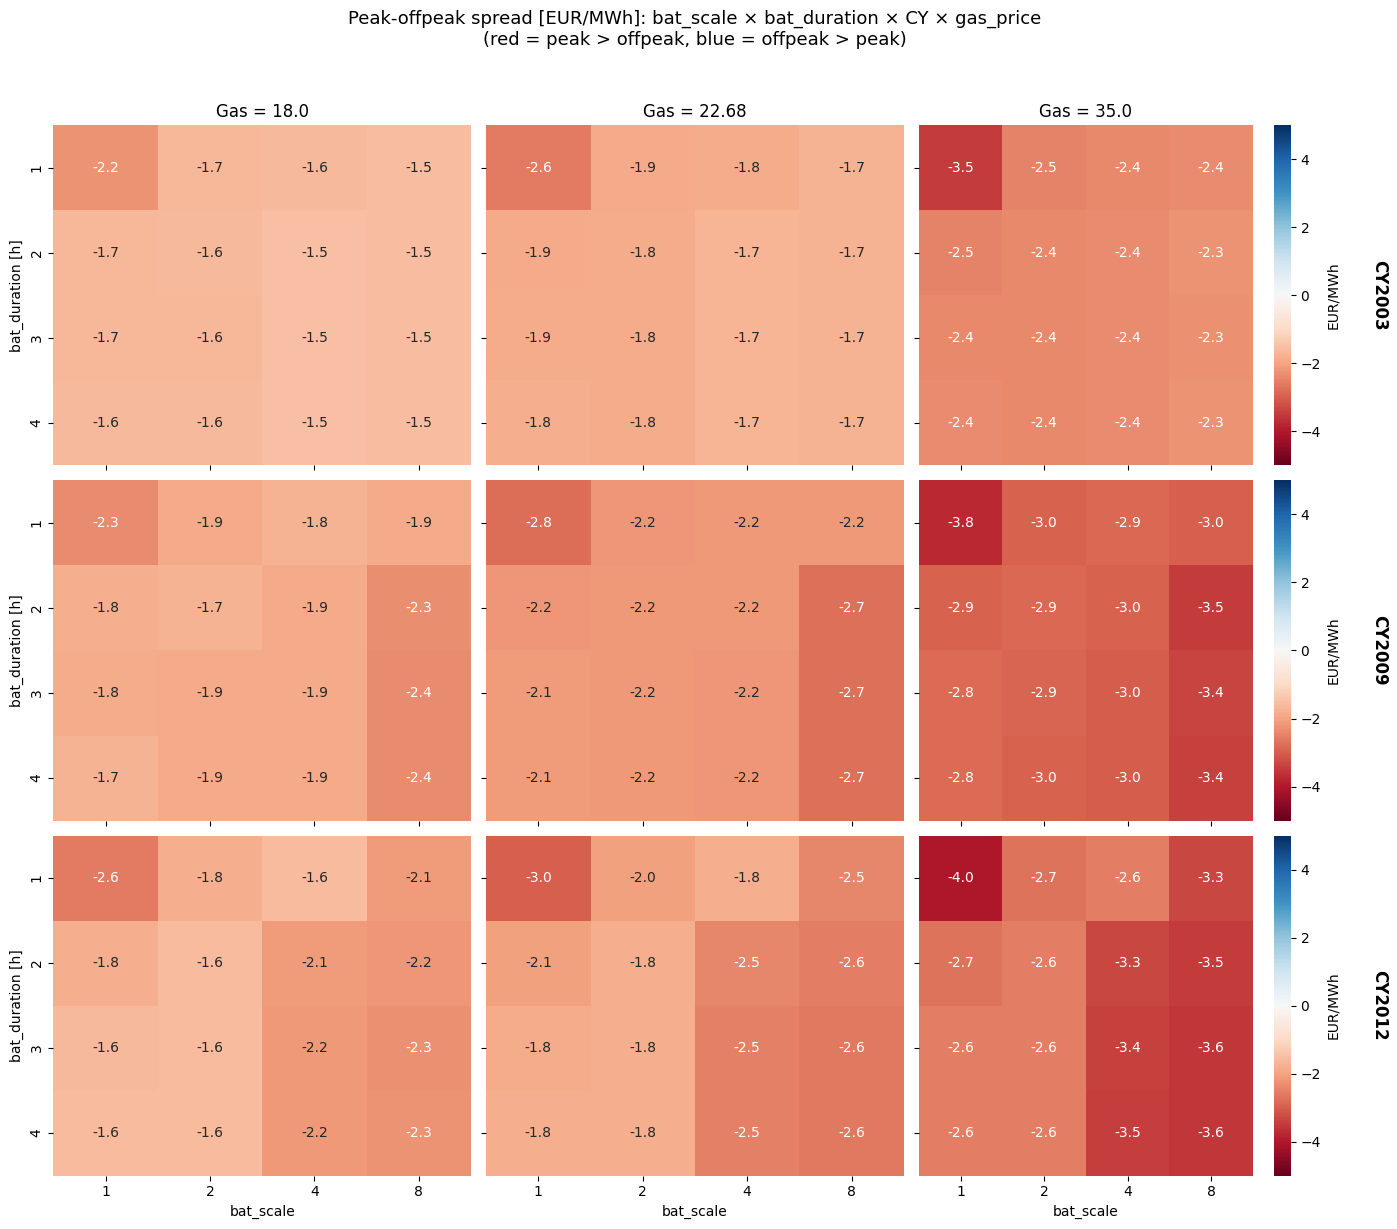

In [ ]:
eu_spread = spread_df.groupby(["tag", "battery_scale", "battery_duration", "climate_year", "gas_price"])["spread"].median().reset_index()

# Heatmap: bat_scale × bat_duration, faceted by climate_year × gas_price
fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=True, sharey=True)

for row, cy in enumerate([2003, 2009, 2012]):
    for col, gp in enumerate([18.0, 22.68, 35.0]):
        ax = axes[row, col]
        sub = eu_spread[(eu_spread["climate_year"] == cy) & (eu_spread["gas_price"] == gp)]
        pivot = sub.groupby(["battery_duration", "battery_scale"])["spread"].median().reset_index()
        hm = pivot.pivot(index="battery_duration", columns="battery_scale", values="spread")

        sns.heatmap(hm, annot=True, fmt=".1f", cmap="RdBu", center=0, ax=ax,
                    cbar=col == 2, vmin=-5, vmax=5,
                    cbar_kws={"label": "EUR/MWh"} if col == 2 else {})
        ax.set_xlabel("bat_scale" if row == 2 else "")
        ax.set_ylabel("bat_duration [h]" if col == 0 else "")

        if row == 0:
            ax.set_title(f"Gas = {gp}")
        if col == 2:
            ax.yaxis.set_label_position("right")
            ax.text(1.35, 0.5, f"CY{cy}", transform=ax.transAxes,
                    rotation=-90, va="center", fontsize=12, fontweight="bold")

plt.suptitle("Peak-offpeak spread [EUR/MWh]: bat_scale \u00d7 bat_duration \u00d7 CY \u00d7 gas_price\n(red = peak > offpeak, blue = offpeak > peak)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# EU-wide median spread per scenario
eu_spread_reg = spread_df.groupby(["tag", "battery_scale", "battery_duration",
                                    "gas_price", "co2_price", "climate_year"])["spread"].median().reset_index()

X = eu_spread_reg[["battery_scale", "battery_duration", "gas_price", "co2_price", "climate_year"]].astype(float)
X = sm.add_constant(X)
y = eu_spread_reg["spread"].astype(float)
model_spread = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 10})

print("Spread regression (HAC):")
print(f"R² = {model_spread.rsquared:.3f}")
print()
for var in ["battery_scale", "battery_duration", "gas_price", "co2_price", "climate_year"]:
    sig = "***" if model_spread.pvalues[var] < 0.001 else "**" if model_spread.pvalues[var] < 0.01 else "*" if model_spread.pvalues[var] < 0.05 else "ns"
    print(f"  {var:20s}: {model_spread.params[var]:+.4f}  (t={model_spread.tvalues[var]:.2f}) {sig}")

Spread regression (HAC):
R² = 0.752

  battery_scale       : -0.0282  (t=-4.28) ***
  battery_duration    : +0.0408  (t=1.75) ns
  gas_price           : -0.0620  (t=-22.04) ***
  co2_price           : -0.0098  (t=-10.78) ***
  climate_year        : -0.0524  (t=-7.94) ***


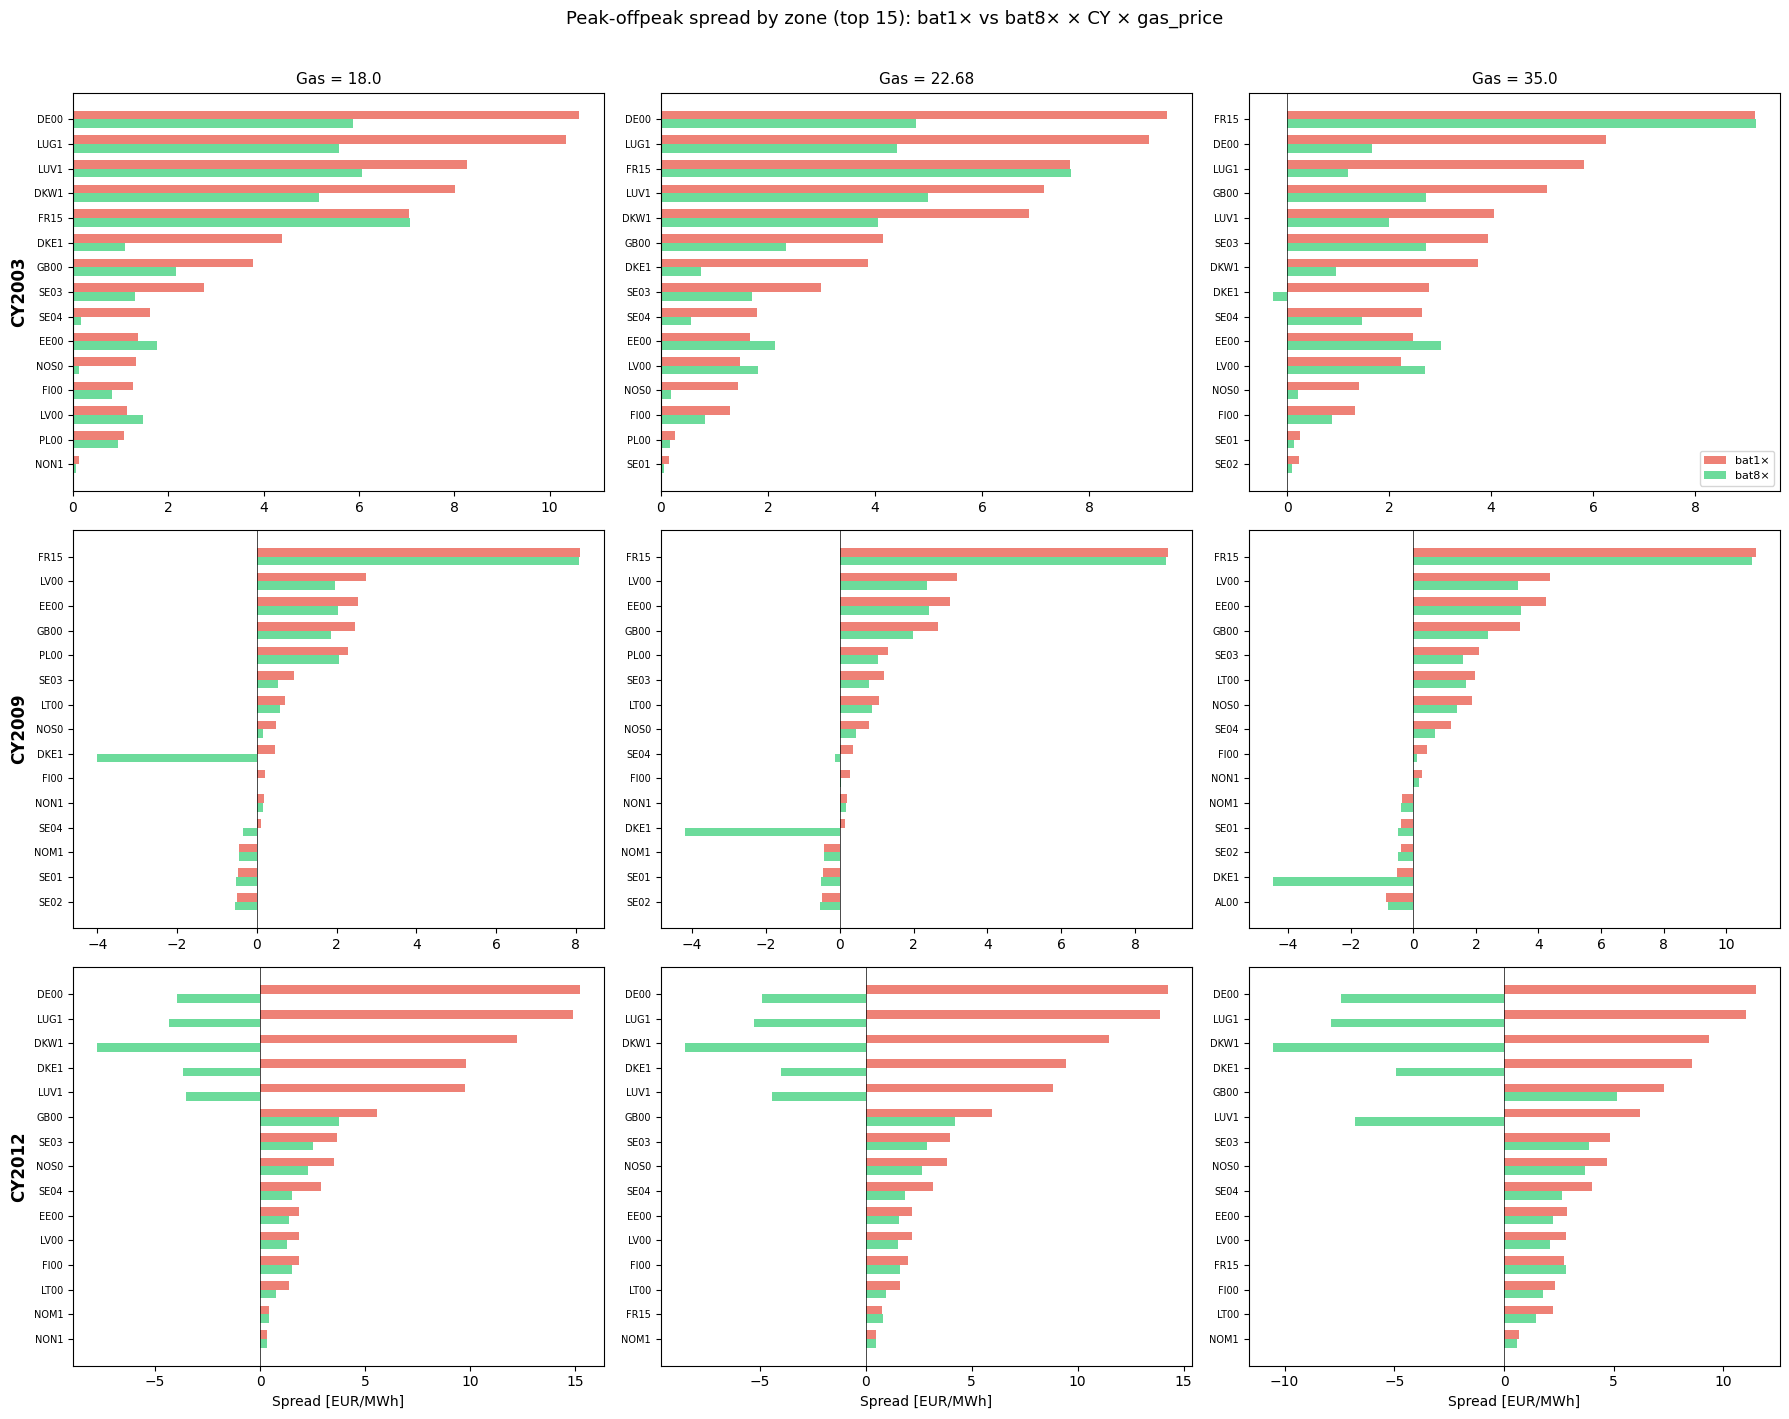

In [ ]:
# Spread per zone — 3×3 grid (CY rows × gas cols)
# Each panel: top 15 zones by |spread| at bat1×, comparing bat1× vs bat8×
CYS = [2003, 2009, 2012]
GAS = [18.0, 22.68, 35.0]
TOP_N = 15

fig, axes = plt.subplots(3, 3, figsize=(18, 14), sharex=False, sharey=False)

for row, cy in enumerate(CYS):
    for col, gp in enumerate(GAS):
        ax = axes[row, col]
        sub = spread_df[(spread_df["climate_year"] == cy) & (spread_df["gas_price"] == gp)]

        s1 = sub[sub["battery_scale"] == 1].groupby("zone")["spread"].median().sort_values(ascending=False)
        s8 = sub[sub["battery_scale"] == 8].groupby("zone")["spread"].median()

        top_zones = s1.head(TOP_N).index
        s1_top = s1.loc[top_zones]
        s8_top = s8.reindex(top_zones)

        x = np.arange(TOP_N)
        w = 0.35
        ax.barh(x - w/2, s1_top.values, w, label="bat1×", color="#e74c3c", alpha=0.7)
        ax.barh(x + w/2, s8_top.values, w, label="bat8×", color="#2ecc71", alpha=0.7)
        ax.set_yticks(x)
        ax.set_yticklabels(top_zones, fontsize=7)
        ax.invert_yaxis()
        ax.axvline(0, color="k", lw=0.5)

        if row == 0:
            ax.set_title(f"Gas = {gp}", fontsize=11)
        if col == 0:
            ax.set_ylabel(f"CY{cy}", fontsize=12, fontweight="bold")
        if row == 2:
            ax.set_xlabel("Spread [EUR/MWh]")
        if row == 0 and col == 2:
            ax.legend(fontsize=8, loc="lower right")

plt.suptitle("Peak-offpeak spread by zone (top 15): bat1× vs bat8× × CY × gas_price", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## B. Technology Capture Rates

Capture rate = generation-weighted average price / system average price.
- CR > 1: technology generates when prices are above average (e.g., gas peakers)
- CR < 1: technology generates when prices are below average (e.g., solar midday)

Batteries should increase solar/wind CR (absorb surplus → lift low-price hours)
and decrease gas CR (replace peaks → lower peak prices).

In [ ]:
# Capture rate computation (data already loaded in Cell 1)
cr_records = []

for i, tag in enumerate(results["tag"].values):
    lmp_tag = lmp_all[lmp_all["tag"] == tag][bus_cols].values  # 8760 x 55
    gen_tag = gen_p_all[gen_p_all["tag"] == tag][gen_cols].values  # 8760 x 557

    # System average price (generation-weighted)
    total_gen_per_zone = np.zeros(len(bus_cols))
    for gi, gname in enumerate(gen_cols):
        if gname in static_gen.index:
            bus = static_gen.loc[gname, "bus"]
            if bus in bus_cols:
                bi = bus_cols.index(bus)
                total_gen_per_zone[bi] += gen_tag[:, gi].sum()

    sys_price = np.sum(lmp_tag.mean(axis=0) * total_gen_per_zone) / total_gen_per_zone.sum() if total_gen_per_zone.sum() > 0 else np.nan

    for carrier in KEY_CARRIERS:
        units = static_gen[static_gen["carrier"] == carrier].index
        units_in = [u for u in units if u in gen_cols]
        if not units_in:
            continue

        total_revenue = 0
        total_generation = 0
        for u in units_in:
            gi = gen_cols.index(u)
            bus = static_gen.loc[u, "bus"]
            if bus not in bus_cols:
                continue
            bi = bus_cols.index(bus)
            gen_u = gen_tag[:, gi]
            lmp_u = lmp_tag[:, bi]
            total_revenue += (gen_u * lmp_u).sum()
            total_generation += gen_u.sum()

        if total_generation > 0 and sys_price > 0:
            capture_price = total_revenue / total_generation
            cr = capture_price / sys_price
            cr_records.append({"tag": tag, "carrier": carrier, "capture_rate": cr,
                              "capture_price": capture_price, "sys_price": sys_price})

    if (i + 1) % 100 == 0:
        print(f"  Processed {i+1}/432...")

cr_df = pd.DataFrame(cr_records).merge(
    results[["tag", "battery_scale", "battery_duration", "gas_price", "co2_price", "climate_year"]],
    on="tag"
)
print(f"Capture rate data: {len(cr_df)} rows")
print(f"\nMean capture rate by carrier:")
print(cr_df.groupby("carrier")["capture_rate"].mean().round(3).sort_values(ascending=False))

  Processed 100/432...
  Processed 200/432...
  Processed 300/432...
  Processed 400/432...
Capture rate data: 2592 rows

Mean capture rate by carrier:
carrier
gas                 1.619
nuclear             1.082
hydro-ror           1.078
onwind              0.810
offwind             0.746
solar-pv-utility    0.694
Name: capture_rate, dtype: float64


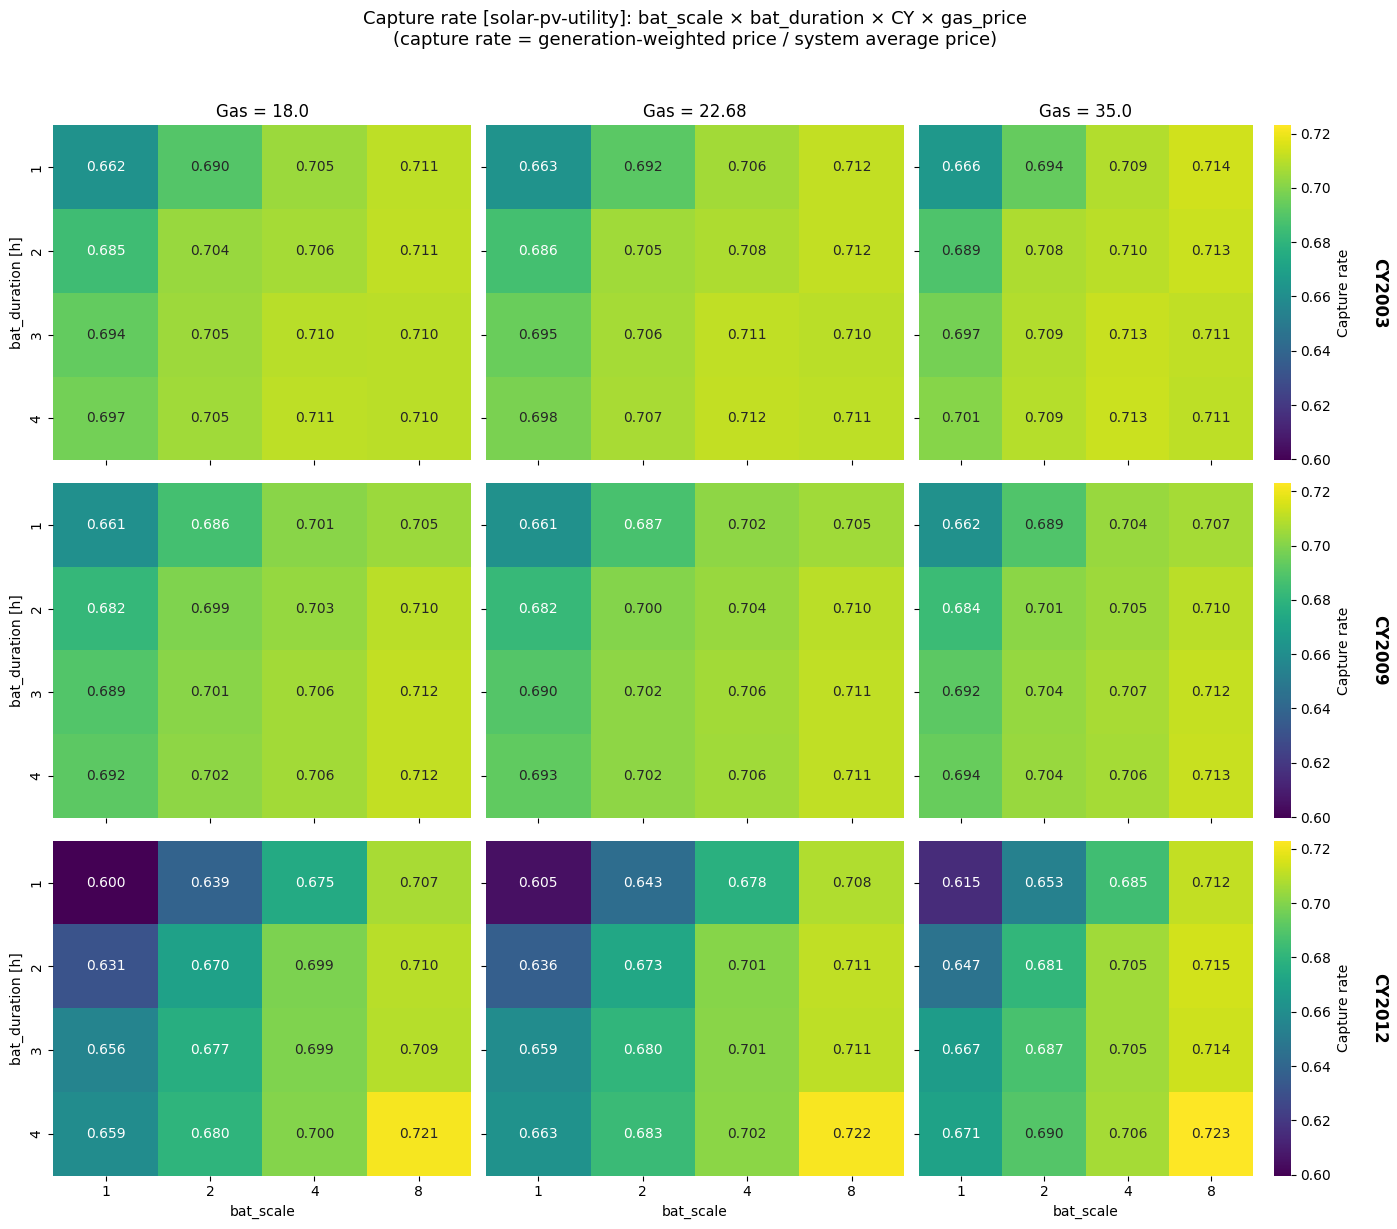

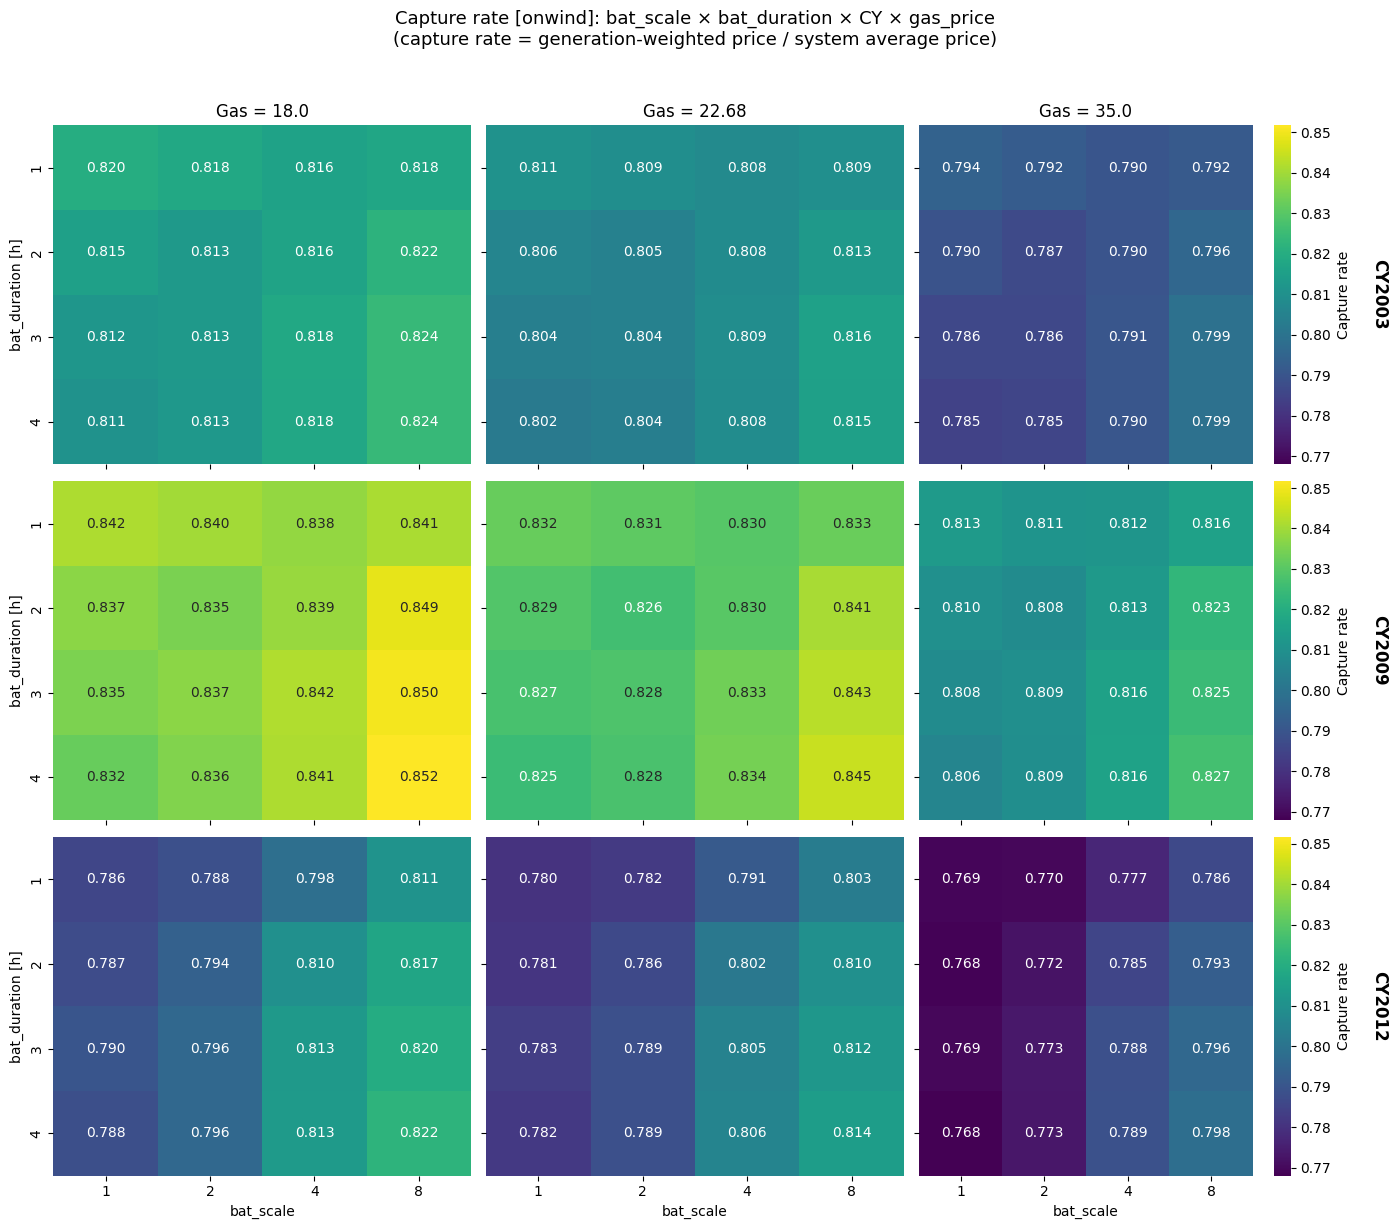

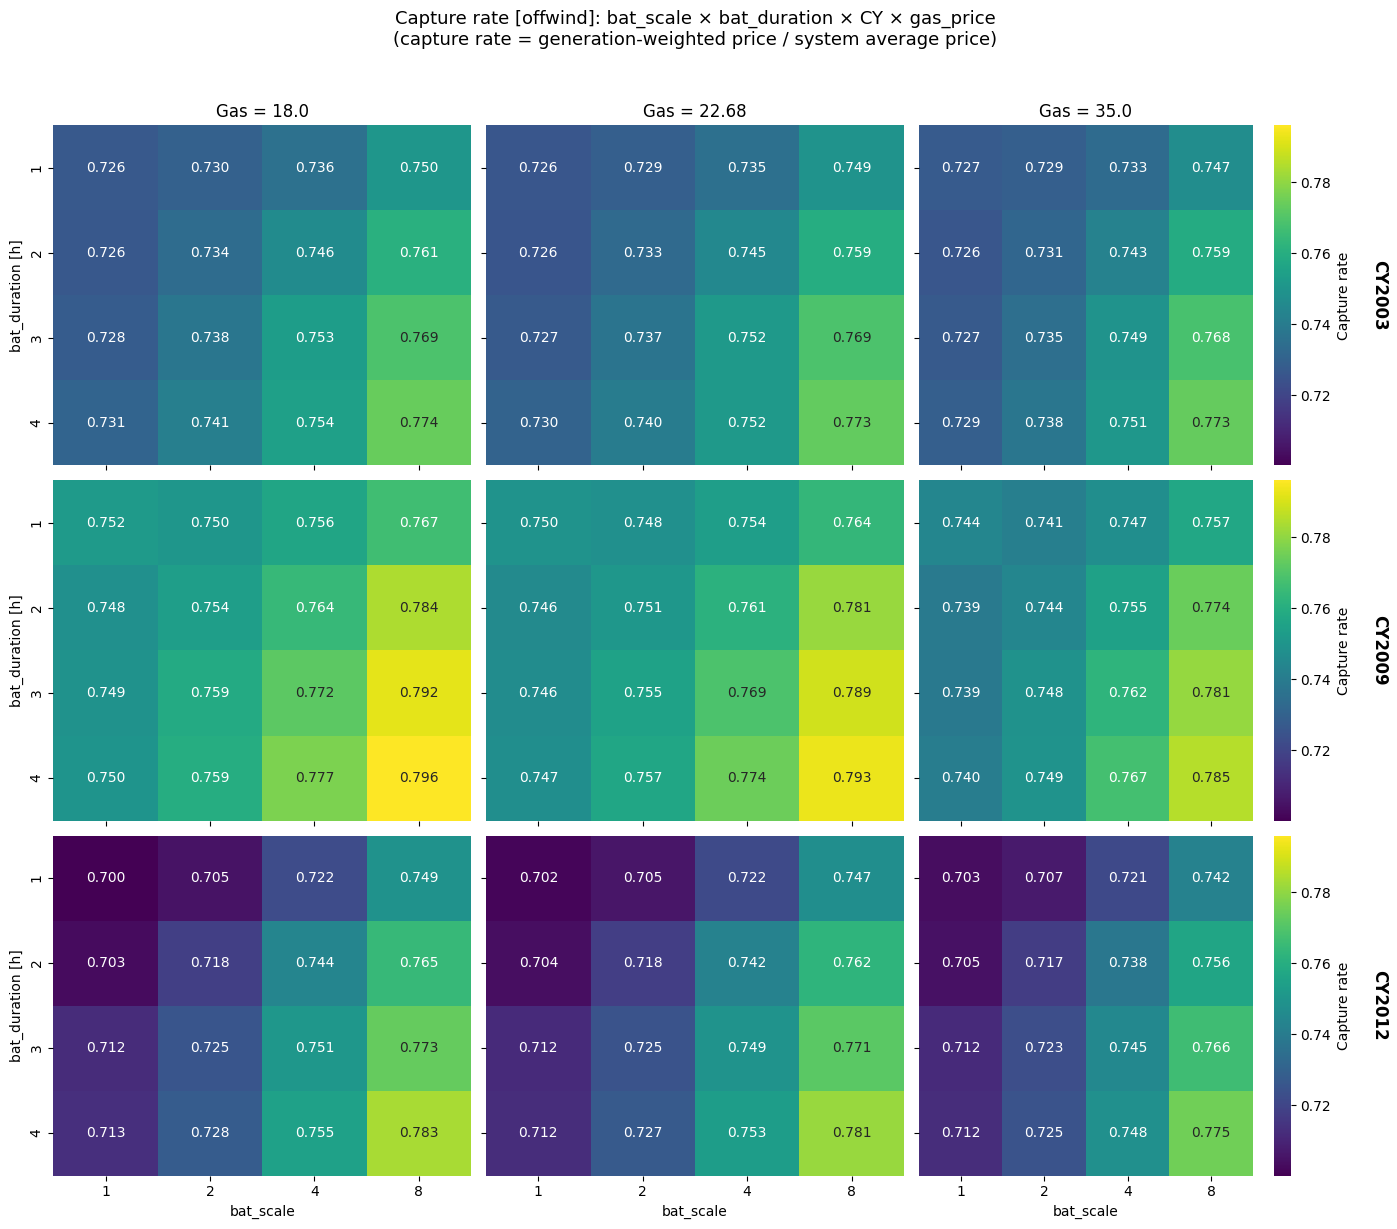

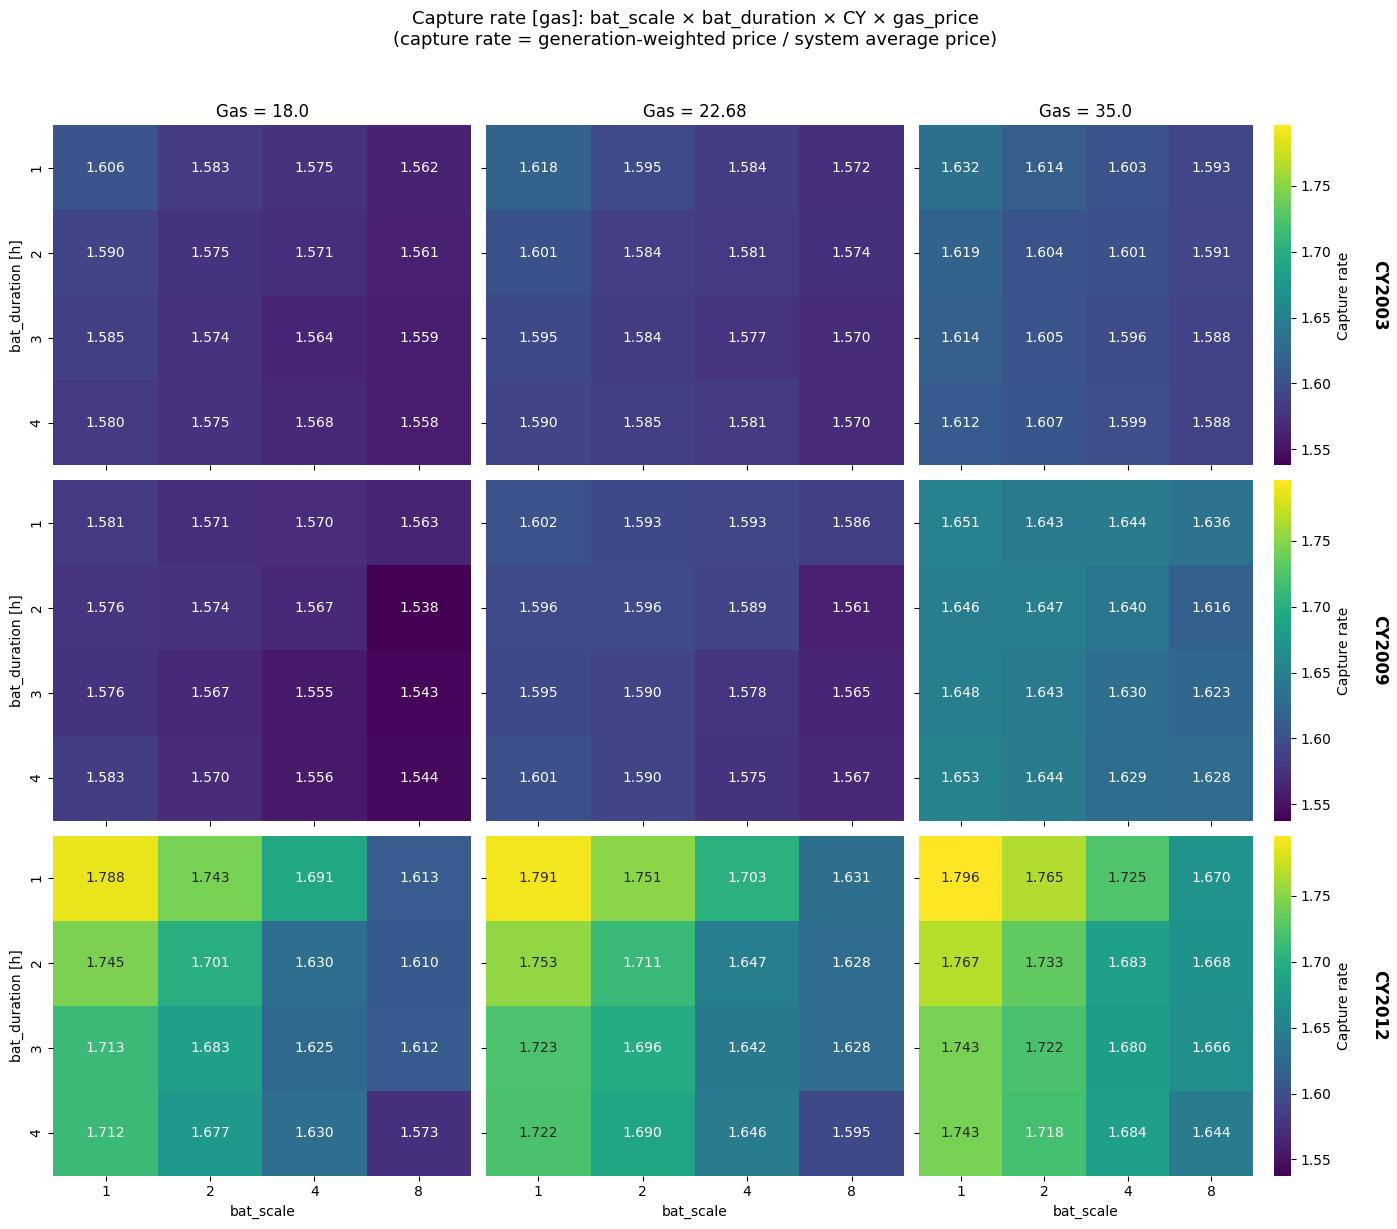

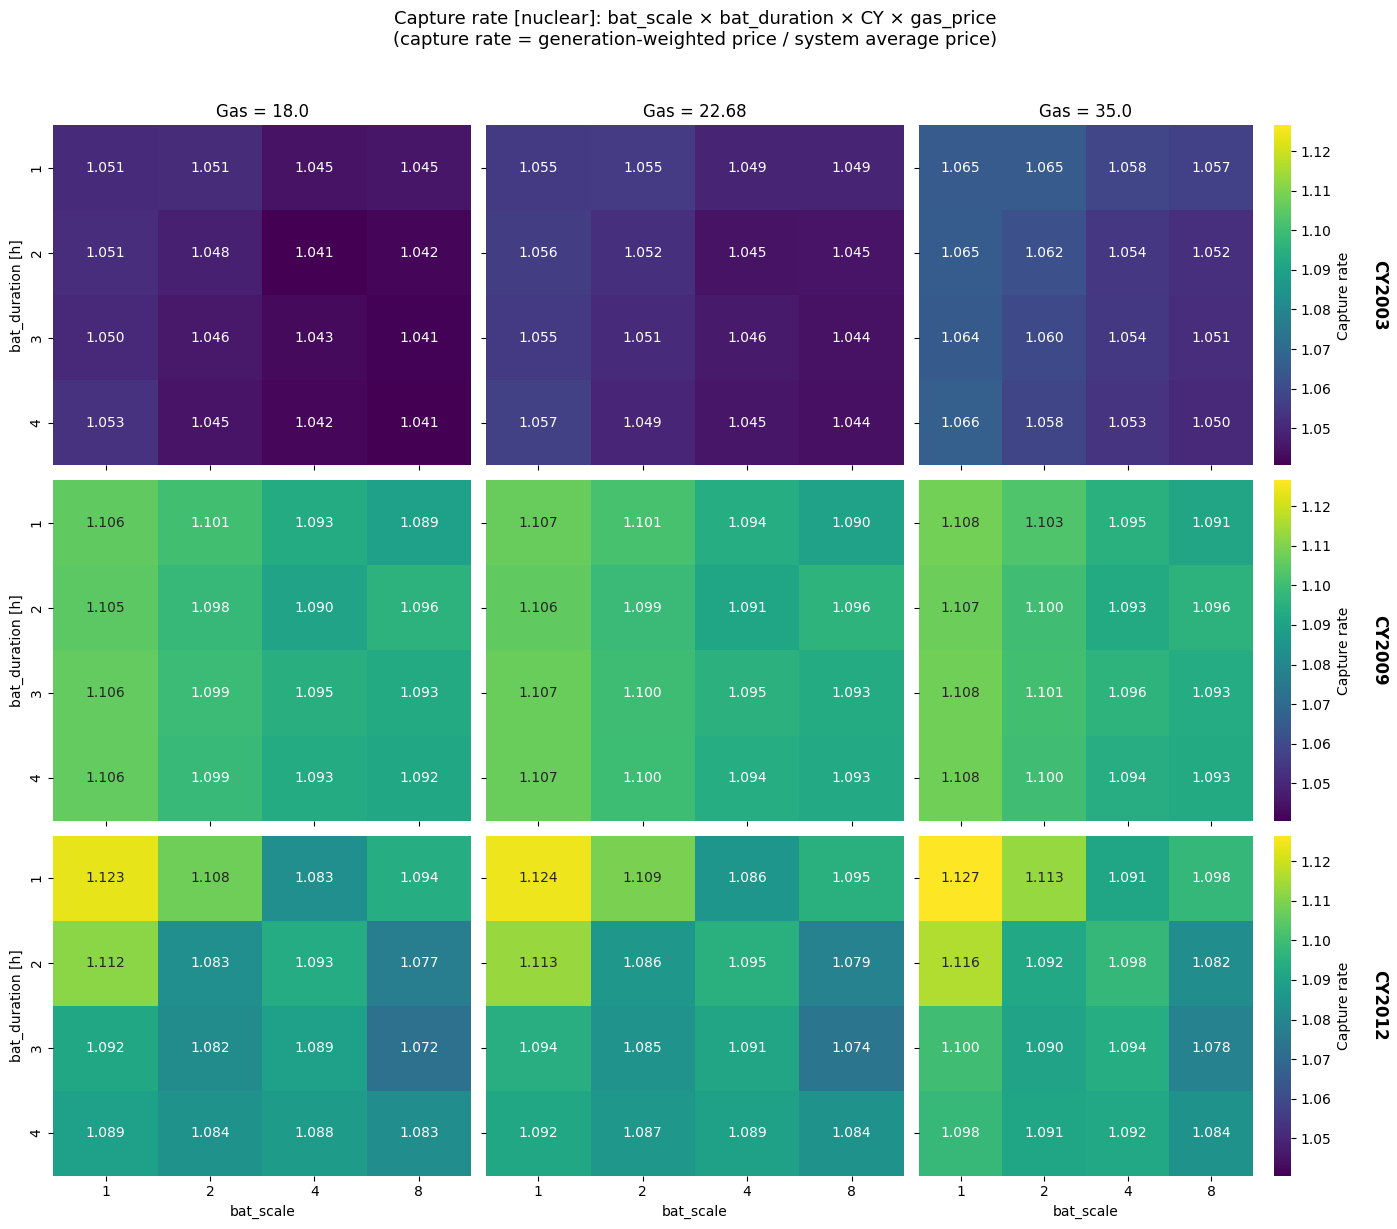

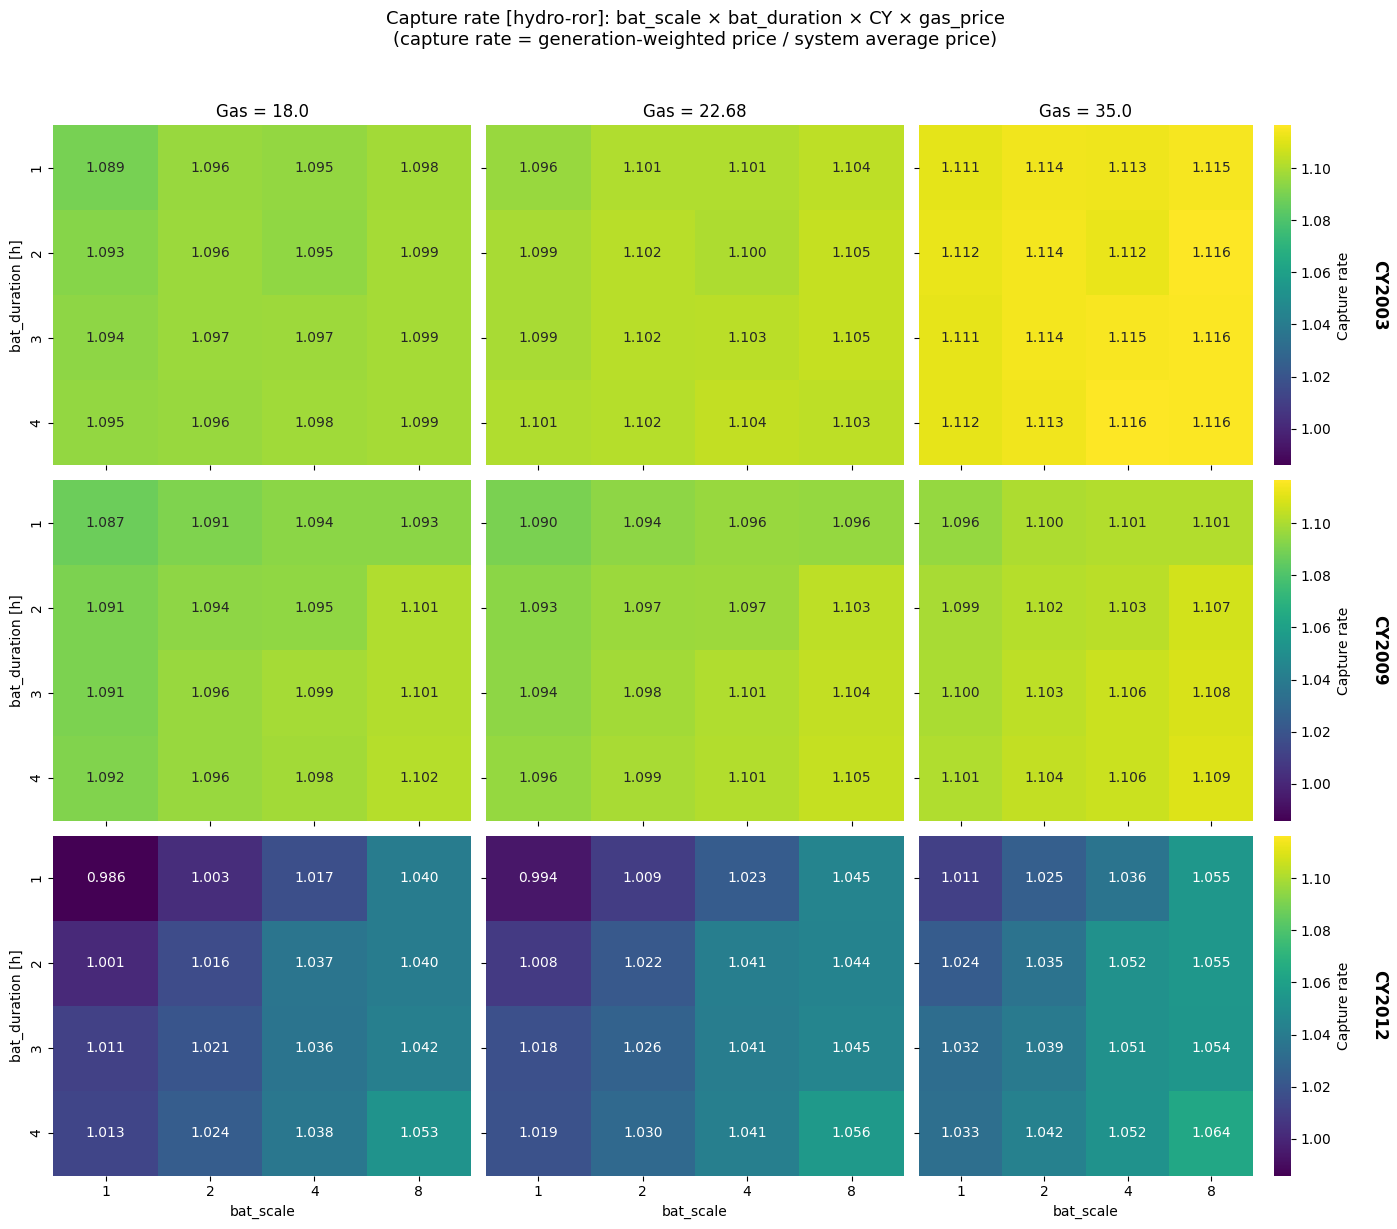

In [ ]:
# Capture rate — one 3×3 heatmap per carrier (CY rows × gas cols, bat_scale × bat_duration inside)
CYS = [2003, 2009, 2012]
GAS = [18.0, 22.68, 35.0]

for carrier in KEY_CARRIERS:
    cr_carrier = cr_df[cr_df["carrier"] == carrier]
    if cr_carrier.empty:
        continue

    fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=True, sharey=True)

    # Per-carrier color range (no forced center — let data speak)
    all_medians = cr_carrier.groupby(["climate_year", "gas_price", "battery_duration", "battery_scale"])["capture_rate"].median()
    vmin, vmax = all_medians.min(), all_medians.max()

    for row, cy in enumerate(CYS):
        for col, gp in enumerate(GAS):
            ax = axes[row, col]
            sub = cr_carrier[(cr_carrier["climate_year"] == cy) & (cr_carrier["gas_price"] == gp)]
            pivot = sub.groupby(["battery_duration", "battery_scale"])["capture_rate"].median().reset_index()
            hm = pivot.pivot(index="battery_duration", columns="battery_scale", values="capture_rate")

            sns.heatmap(hm, annot=True, fmt=".3f", cmap="viridis", ax=ax,
                        cbar=col == 2, vmin=vmin, vmax=vmax,
                        cbar_kws={"label": "Capture rate"} if col == 2 else {})
            ax.set_xlabel("bat_scale" if row == 2 else "")
            ax.set_ylabel("bat_duration [h]" if col == 0 else "")

            if row == 0:
                ax.set_title(f"Gas = {gp}")
            if col == 2:
                ax.yaxis.set_label_position("right")
                ax.text(1.35, 0.5, f"CY{cy}", transform=ax.transAxes,
                        rotation=-90, va="center", fontsize=12, fontweight="bold")

    plt.suptitle(f"Capture rate [{carrier}]: bat_scale × bat_duration × CY × gas_price\n(capture rate = generation-weighted price / system average price)", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

In [ ]:
# Battery capture ratio (data already loaded in Cell 1)
bat_units = static_su[static_su["carrier"] == "battery"].index

bat_records = []
for i, tag in enumerate(results["tag"].values):
    stor_tag = stor_p_all[stor_p_all["tag"] == tag][stor_cols].values
    lmp_tag = lmp_all[lmp_all["tag"] == tag][bus_cols].values

    total_discharge_rev = 0
    total_discharge_mwh = 0
    total_charge_cost = 0
    total_charge_mwh = 0

    for u in bat_units:
        if u not in stor_cols:
            continue
        si = stor_cols.index(u)
        bus = static_su.loc[u, "bus"]
        if bus not in bus_cols:
            continue
        bi = bus_cols.index(bus)

        p = stor_tag[:, si]
        lmp_u = lmp_tag[:, bi]

        discharge = np.where(p > 0, p, 0)
        charge = np.where(p < 0, -p, 0)

        total_discharge_rev += (discharge * lmp_u).sum()
        total_discharge_mwh += discharge.sum()
        total_charge_cost += (charge * lmp_u).sum()
        total_charge_mwh += charge.sum()

    if total_discharge_mwh > 0 and total_charge_mwh > 0:
        bat_records.append({
            "tag": tag,
            "avg_discharge_price": total_discharge_rev / total_discharge_mwh,
            "avg_charge_price": total_charge_cost / total_charge_mwh,
            "capture_ratio": (total_discharge_rev / total_discharge_mwh) / (total_charge_cost / total_charge_mwh),
        })

    if (i + 1) % 100 == 0:
        print(f"  Processed {i+1}/432...")

bat_df = pd.DataFrame(bat_records).merge(
    results[["tag", "battery_scale", "battery_duration", "gas_price", "co2_price", "climate_year"]],
    on="tag"
)



  Processed 100/432...
  Processed 200/432...
  Processed 300/432...
  Processed 400/432...


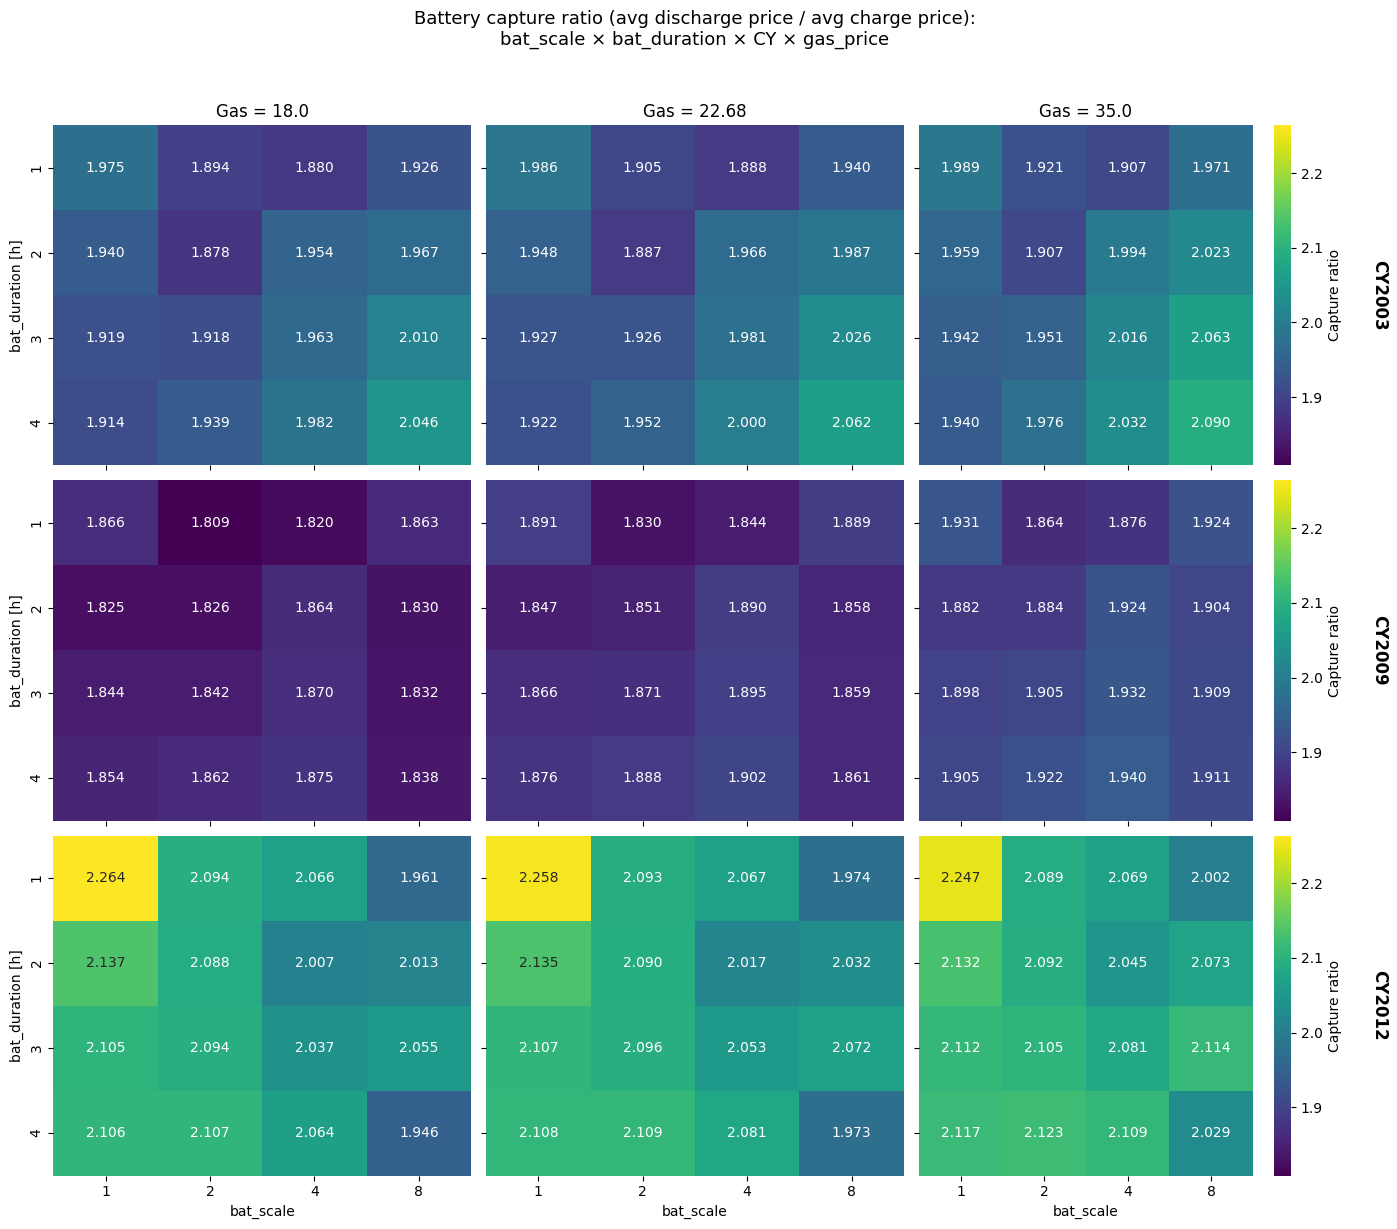

Mean capture ratio by bat_scale × bat_duration:
battery_duration      1      2      3      4
battery_scale                               
1                 2.046  1.978  1.969  1.971
2                 1.944  1.945  1.968  1.986
4                 1.935  1.962  1.980  1.998
8                 1.939  1.964  1.993  1.972

Avg discharge price: 70.4 EUR/MWh
Avg charge price: 35.6 EUR/MWh


In [ ]:
# 3×3 heatmap: CY rows × gas cols, bat_scale × bat_duration inside
CYS = [2003, 2009, 2012]
GAS = [18.0, 22.68, 35.0]

fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=True, sharey=True)

all_medians = bat_df.groupby(["climate_year", "gas_price", "battery_duration", "battery_scale"])["capture_ratio"].median()
vmin, vmax = all_medians.min(), all_medians.max()

for row, cy in enumerate(CYS):
    for col, gp in enumerate(GAS):
        ax = axes[row, col]
        sub = bat_df[(bat_df["climate_year"] == cy) & (bat_df["gas_price"] == gp)]
        pivot = sub.groupby(["battery_duration", "battery_scale"])["capture_ratio"].median().reset_index()
        hm = pivot.pivot(index="battery_duration", columns="battery_scale", values="capture_ratio")

        sns.heatmap(hm, annot=True, fmt=".3f", cmap="viridis", ax=ax,
                    cbar=col == 2, vmin=vmin, vmax=vmax,
                    cbar_kws={"label": "Capture ratio"} if col == 2 else {})
        ax.set_xlabel("bat_scale" if row == 2 else "")
        ax.set_ylabel("bat_duration [h]" if col == 0 else "")

        if row == 0:
            ax.set_title(f"Gas = {gp}")
        if col == 2:
            ax.yaxis.set_label_position("right")
            ax.text(1.35, 0.5, f"CY{cy}", transform=ax.transAxes,
                    rotation=-90, va="center", fontsize=12, fontweight="bold")

plt.suptitle("Battery capture ratio (avg discharge price / avg charge price):\nbat_scale × bat_duration × CY × gas_price", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Summary stats
print("Mean capture ratio by bat_scale × bat_duration:")
print(bat_df.groupby(["battery_scale", "battery_duration"])["capture_ratio"].mean().unstack().round(3))
print(f"\nAvg discharge price: {bat_df['avg_discharge_price'].mean():.1f} EUR/MWh")
print(f"Avg charge price: {bat_df['avg_charge_price'].mean():.1f} EUR/MWh")

## Summary & Limitations

### Key Findings

**A. Peak-Offpeak Spread:**
1. The traditional peak-offpeak spread is **inverted** in the 2030 model — offpeak hours (nights + weekends) are on average 2–3 EUR/MWh more expensive than peak hours (08-20 Mon-Fri). This is driven by the solar duck curve: massive midday solar suppresses prices during peak hours, while evening ramp-up (20-23h, classified as offpeak) drives prices to 75–84 EUR/MWh.
2. Batteries deepen this inversion — bat_scale β = −0.028 (t = −4.28, p < 0.001). More batteries charge during cheap solar peak and discharge during expensive evening offpeak.
3. Gas price is the strongest predictor of spread (β = −0.062, t = −22.04, p < 0.001) — higher gas amplifies the offpeak premium as gas-fired peakers set evening prices.
4. bat_duration has no significant effect on spread (β = +0.041, t = 1.75, ns).
5. Overall model R² = 0.752 — spread is well-explained by the scenario parameters.

**B. Capture Rates:**
6. Solar capture rate increases with bat_scale (from ~0.60 to ~0.72) — batteries absorb midday surplus, reducing price cannibalization of solar generation. Effect is strongest in CY2012 (cold year with higher demand).
7. Battery capture ratio (avg discharge price / avg charge price) remains well above 1.0 across all scenarios (range 1.8–2.3). Batteries discharge at ~70 EUR/MWh and charge at ~36 EUR/MWh on average. **Important caveat:** these ratios represent an upper bound due to the LP model's perfect foresight — real-world battery arbitrage ratios are typically 1.2–1.5 (Staffell & Rustomji 2016). The comparative effect across scenarios (how ratio changes with bat_scale, gas_price, etc.) remains valid.
8. Capture ratio slightly decreases with bat_scale (e.g. 2.05 → 1.94 at 1h duration) — more batteries compress the price spread they exploit, but the effect is modest.

### Synthesis

Batteries reshape the temporal structure of electricity prices:
- They deepen the **inverted peak-offpeak spread** caused by solar penetration (traditional peak is now cheaper than offpeak)
- They lift **solar capture rates** by ~20% (reducing price cannibalization)
- They maintain strong **arbitrage value** even at 8× capacity scaling, though with modest self-cannibalization

### Limitations

1. **LP model** — no unit commitment; real peak-offpeak dynamics involve start-up costs and ramping constraints. Perfect foresight inflates battery arbitrage revenue.
2. **Uniform battery scaling** — all zones scaled equally; real deployment is heterogeneous
3. **Fixed peak definition (08-20 Mon-Fri)** — this traditional definition is inverted in the 2030 high-solar model. The actual price peak occurs at 17-21h. Results should be interpreted as "traditional peak block vs offpeak block" rather than "expensive vs cheap hours"
4. **Capture rate is aggregate** — per-zone capture rates may differ significantly from the EU-wide figures